# Lecture 9


Some of the examples today are inspired by [Python Practice Book](https://anandology.com/python-practice-book/object_oriented_programming.html).



## Rational Numbers

Keeping fractions as fractions doesn't require a class. You could carry each fraction around as a pair, a numerator and a denominator, and write functions that take two pairs and hand back a new pair: add this pair to that pair. That works, but every calculation becomes a function call, and you have to know which function to call. A class puts all of that behind an abstraction. Once `RationalNumber` defines what adding means, you write `a + b`, and Python makes the function call for you when it sees the operator. The expressions you write look like the math, not like bookkeeping.

Lets write a class that keeps fractions as fractions when doing computations:

In [1]:
class RationalNumber:
    """
    Rational Numbers with support for arthmetic operations.

        >>> a = RationalNumber(1, 2)
        >>> b = RationalNumber(1, 3)
        >>> a + b
        5/6
        >>> a - b
        1/6
        >>> a * b
        1/6
        >>> a/b
        3/2
    """
    def __init__(self, numerator, denominator=1):
        self.n = numerator
        self.d = denominator

    def __add__(self, other):
        if not isinstance(other, RationalNumber):
            other = RationalNumber(other)

        n = self.n * other.d + self.d * other.n
        d = self.d * other.d
        return RationalNumber(n, d)

    def __sub__(self, other):
        if not isinstance(other, RationalNumber):
            other = RationalNumber(other)

        n1, d1 = self.n, self.d
        n2, d2 = other.n, other.d
        return RationalNumber(n1*d2 - n2*d1, d1*d2)

    def __mul__(self, other):
        if not isinstance(other, RationalNumber):
            other = RationalNumber(other)

        n1, d1 = self.n, self.d
        n2, d2 = other.n, other.d
        return RationalNumber(n1*n2, d1*d2)

    def __truediv__(self, other):
        if not isinstance(other, RationalNumber):
            other = RationalNumber(other)

        n1, d1 = self.n, self.d
        n2, d2 = other.n, other.d
        return RationalNumber(n1*d2, d1*n2)

    def __str__(self):
        return "%s/%s" % (self.n, self.d)

    __repr__ = __str__

In [2]:
RationalNumber(1,2)

1/2

In [3]:
print(RationalNumber(1,2) + RationalNumber(1,2))
print(RationalNumber(1,2) - RationalNumber(1,2))
print(RationalNumber(1,2) * RationalNumber(1,2))
print(RationalNumber(1,2) / RationalNumber(1,2))

4/4
0/4
1/4
2/2


A quick design note before moving on. Printing a `RationalNumber` above works because of `__str__` — the method Python calls when it needs a human-readable string, e.g. for `print`. There's a related method, `__repr__`, that's meant for something more specific: a string that, if you fed it back into `eval`, would reconstruct the exact object — instructions for cloning yourself, not just a description. It's tempting to implement one and let it stand in for the other, since Python will fall back to `__repr__` when `__str__` is missing, but they're answering different questions, and worth keeping distinct: could this string rebuild the object, or is it just meant to be read? This distinction matters again later, when saving and loading objects means asking exactly this: what string, if evaluated, gives me my object back?

Notice also what the class doesn't do: it never simplifies. Above, `1/2 + 1/2` comes out as `4/4`, and `1/2 - 1/2` as `0/4`. A version meant for real use would add one more method that reduces a fraction, taking out the factors the numerator and denominator have in common, and call it after every operation. That is easy to write. It just isn't here.

# An Aside: A Theoretical Model on a T-Shirt

Before we build the particle physics simulation below, a short detour into what it is a simulation *of*. The detour is on purpose. In your work you will keep walking into rooms full of experts who have spent their careers on something you know nothing about. You won't need to become one of them. You need to follow enough of what they say to solve a problem they can't. Particle physics is a good place to practise that, so treat this section as something to follow, not something to memorize.

## Kinds of models

We use the word *model* a lot in this course. Some of our models are built directly from data. A histogram, for example, is a model of a distribution, estimated from samples. Some models are generators: the random number generators you are writing produce data that follows a distribution you chose. The model in this section is a third kind, a **theoretical model**. It is what we know about the world, written down as mathematics.

A theoretical model is built in a loop:

1. **Observe.** Make measurements, and look for the things that always happen the same way.
2. **Encode.** Write those regularities down mathematically. A particle has a position, $x, y, z$, and so on.
3. **Generate.** Use the machinery of physics to turn that encoding into predictions for a scenario. Set up the same situation you observed, and ask what the mathematics says will happen.
4. **Compare.** If I throw something, the model predicts where it lands, and I measure that it landed there, the model is right. If it landed somewhere else, the model is wrong.

A physical theory is not meant to be a model in the sense of an approximation or a copy of the world. It is meant to be our best statement of what reality *is*, the thing that generates everything that happens around us. (In practice it is also an approximation. There is a whole branch of theory, the renormalization group, about how every theory we write is an *effective* theory that works at some scale by ignoring what doesn't matter at that scale. But at any given time, the theory is our best encapsulation of reality.)

## The shirt: the Standard Model

At CERN, the particle physics laboratory in Geneva, the gift shop sells T-shirts, mugs and bags printed with one equation:

$$
\mathcal{L} = -\frac{1}{4}F_{\mu\nu}F^{\mu\nu} + i\bar{\psi}\not{D}\psi + h.c. + \bar{\psi}_i y_{ij}\psi_j\phi + h.c. + |D_\mu\phi|^2 - V(\phi)
$$

This is not a summary or a cartoon of the **Standard Model** of particle physics. It *is* the Standard Model, written in the most compact notation available. (A fully expanded version runs to a page or more; the short form bundles fields into vectors and the details into its symbols.) It is the theoretical model of everything we know about matter and forces, except gravity.

### Why it is called a Lagrangian

Newton gave us forces, and told us how to use them one situation at a time: a ball rolling down an inclined plane, a ball rolling off a table. As mathematicians looked underneath Newton's mechanics, they found the engine that makes it all work. You describe a system by writing down one function, called the **Lagrangian** ($\mathcal{L}$). Then a general machinery, the same for any Lagrangian, hands you the system's equations of motion, its conservation laws, and everything else about how it behaves.

The machinery rests on one principle. To predict the path of a particle, consider every path it could possibly take, and give each path a number called the **action**. The path the particle actually takes, classically, is the one that makes the action stationary. Write Newton's physics as a Lagrangian and Newton's laws come straight back out. Change one assumption in the Lagrangian and the machinery tells you the consequences.

The quantum world works the same way with one change. There you can no longer predict the path of a particle, only the probability of finding it somewhere, and that probability comes from adding up contributions from *all* the possible paths instead of picking out one.

So the Lagrangian is the input to a machine that describes both the classical and the quantum world. You put a Lagrangian in and get the physics out. There is a lot of mathematics in between, but we know how to do it. The same machinery handles classical gravity. It is **quantum gravity** where this formulation fails, and that failure is one of the big open problems in physics.

### What goes into it

The Standard Model combines four big ideas:

1. **Newtonian mechanics** (1600s–1700s): objects with definite positions and velocities. Know those, and you can predict where they will be.
2. **Relativity** (1905): nothing can go faster than the speed of light, and space and time bend to make sure of it. At high speeds, velocities no longer simply add.
3. **Fields** (1800s, from electricity and magnetism): charges don't act on each other at a distance. A charge disturbs a field that fills all of space, the field carries the disturbance at the speed of light, and other charges feel it.
4. **Quantum mechanics** (early 1900s): at very small scales you cannot predict exactly what a particle will do, only probabilities. This is a fundamental feature of reality, not a limitation of our instruments.

Together these make **relativistic quantum field theory**, the language the shirt is written in. Everything is described as fields, functions with a value at every point in space. Where a field is excited, there is a particle. The physics is in how the fields interact: how disturbing one field makes another respond.

## Reading the shirt

The Lagrangian above is built in steps.

**Start with the matter.** A century of colliding particles found that all known matter is made from twelve particles, in three families (generations) with the same structure:

| Generation | Quarks | Leptons |
|---|---|---|
| I | up, down | electron, electron neutrino |
| II | charm, strange | muon, muon neutrino |
| III | top, bottom | tau, tau neutrino |

Each generation is a heavier copy of the one before. The heavier ones decay down to the first generation, and the first generation is us: up and down quarks make protons and neutrons, and with electrons they make atoms. Every other particle ever seen (thousands of them) is some combination of these. On the shirt, $\psi$ is a vector holding one field for each of these particles. A term with just $\psi$ and a derivative describes particles that move freely through space and never interact with anything.

**Demand symmetry, and the forces appear.** Now make the particles interact, but in a way that respects a symmetry. The matter fields are complex-valued, and the requirement is that the physics must not change if you shift a field's complex phase differently at every point in space. A plain derivative breaks that symmetry. To restore it you are *forced* to add a new field. For the simplest symmetry group, U(1), that new field is the photon, and all of electricity and magnetism, everything the 1800s worked out, falls out of this single requirement. Two more symmetry groups give the other two forces:

| Symmetry | New fields | Force |
|---|---|---|
| U(1) | the photon | electromagnetism: atoms, chemistry, almost everything we experience |
| SU(2) | the W and Z bosons | the weak force: most radioactive decay |
| SU(3) | the gluons | the strong force: holds nuclei together, and powers the stars that built the elements |

Nobody adds the forces by hand. They are the price of the symmetry. On the shirt, the slash in $\not{D}$ marks the **covariant derivative**, the derivative that respects these symmetries, and the $F_{\mu\nu}F^{\mu\nu}$ term is the new force fields' own dynamics, how they move through space.

**The catch: the symmetries forbid mass.** Those symmetries do not allow you to write a mass for any particle into the Lagrangian. Put one in and the symmetry breaks, and the whole construction falls over. But the world plainly has mass.

**Add one more field, everywhere.** The way out was the idea of Peter Higgs and others. Add one more field that fills all of space, but which, unlike every other field, is *not* zero everywhere. Its potential, $V(\phi)$, has its minimum away from zero, so as the early universe cooled the field settled into a non-zero value, and it has been switched on ever since. Every particle that interacts with this background field is slowed by it in a way that behaves exactly like mass. The same interactions, the $\bar{\psi}_i y_{ij}\psi_j\phi$ term, also connect the three generations, which is how the heavier ones decay into the lighter ones. Without the Higgs field we can't even calculate with the theory. With it, the predictions work.

Term by term:

| Term | What it is |
|---|---|
| $\psi$ | the matter fields: quarks and leptons, three generations |
| $\partial_\mu$ | the derivative: how fields move through spacetime |
| $D_\mu$ | the covariant derivative: symmetry imposed, which forces in the force fields |
| $F_{\mu\nu}$ | the force fields' kinetic terms: the forces |
| $\phi$, $V(\phi)$ | the Higgs field and its potential: mass, and the mixing between generations |

Give this equation, the machinery for using it, and the 19 measured numbers described next, to a civilization that knew nothing else about our universe, and they would know everything we know about particles and forces.

## What the shirt doesn't show: 19 numbers

The shirt fixes the *form* of the theory. Symmetry dictates which terms are allowed. What it does not print are the numbers that go into those terms, and the theory cannot predict them: they have to be measured. The Standard Model has **19 free parameters**:

| Parameters | How many |
|---|---:|
| quark masses | 6 |
| charged lepton masses (electron, muon, tau) | 3 |
| strengths of the three forces | 3 |
| quark mixing between generations (the CKM matrix) | 4 |
| the Higgs field's background value and the Higgs boson's mass | 2 |
| one more strong-force parameter (the "QCD vacuum angle") | 1 |
| **total** | **19** |

(This count takes neutrinos to be massless, as the original Standard Model does. We now know they have tiny masses, which needs a few more parameters.)

Nineteen measured numbers plus one line of symbols. In data science terms, the shirt is the model and the 19 numbers are its fitted parameters.

## How good is it? Right about 5% of the universe

With those 19 numbers measured, the Standard Model gets every experiment we can do on ordinary matter right, often to as much precision as we can measure. It is arguably the most successful theory anyone has written down.

It also has clear limits. Everything it describes, all the matter we know about, all the stars and planets and people, is about **5%** of the content of the universe. About 27% is **dark matter** and about 68% is **dark energy**, and we don't know what either one is. Gravity isn't in the Lagrangian at all. So the shirt is complete for the 5% we understand, and silent about the rest.

## From a theory to a simulation

So we have a theoretical model. How do we actually *use* it to see what can happen?

Here is the problem this lecture works through. Go back in time to just after Peter Higgs and others proposed the Higgs field. (The Higgs boson was found in 2012, and the 2013 Nobel Prize went to Higgs and François Englert, two of the theorists who proposed it.) You are an experimental particle physicist and you want to find the Higgs boson. Because it couples to so many particles, a Higgs boson decays almost the instant it is made, so you will never see it directly, only what it decays into. One of the cleanest decays is to two photons, $H\rightarrow\gamma\gamma$, and it was one of the main ways the Higgs was eventually seen. To find it, you have to build a detector that can measure those photons. **What photon energies does your detector need to handle?**

The theory can tell you the answer in principle, but not as a single number. The Lagrangian predicts *probabilities*: how likely a Higgs is to be produced with a given momentum, how likely it is to decay one way or another. Each collision is one random outcome. Real Higgs bosons are produced with a spread of momenta, so the photons come out with a spread of energies. The answer to "what energies" is a distribution. For anything as complicated as a real detector, working that distribution out with pen and paper is hopeless.

What you can do is **simulate** it. Generate a large number of random collisions, each one following the rules the theory lays down, and histogram what comes out. That is a **Monte Carlo simulation**, and it is how particle physicists get from the equation on the shirt to a number an engineer can build to. It is also where the random-number tools of this course come in:

1. **Draw.** Pick how fast each Higgs is moving by drawing a random number from a distribution. The accept/reject generator from your lab can produce draws from *any* distribution you give it. Below we use a normal distribution, and a faster generator built specially for it.
2. **Decay.** In the Higgs' own rest frame a two-body decay is simple: the two photons share its energy equally and fly off back to back.
3. **Boost.** Use special relativity to transform the photons from the Higgs' rest frame into the frame of the lab, where the detector sits.
4. **Look.** Repeat many times, and histogram the photon energies. That histogram is the design spec for your detector.

The rest of this lecture builds exactly this. The physics needs relativistic four-vectors, and doing that bookkeeping by hand is error-prone, which is why it becomes a good case for a class.

# Particle Physics Example

Let's try to do something more meaningful and introduce some particle physics basics. Imagine you 
are thinking about building an experiment to study the Higgs boson. You have an accelerator that will produce this Higgs by colliding other particles together at high energies. The Higgs boson decays very quickly, so you won't see it directly. Instead, you'll only be able to observe the particles that the Higgs decays into. You'll need to design and build a detector that can see these decay products. Before you get started, you want to know what are the energies of the particles, so you can design a detector that performs well for Higgs studies. Lets build a simulation to extract an estimate of these energies.

## Relativistic Mechanics

Since everything will be moving close to the speed of light, we'll need to employ relativistic mechanics
to write down the equations behind our simulation. In relativistic mechanics, the Energy and Momentum of particles are different in every frame, but obey $m^2=E^2-\vec{p}^2$ or $E^2=\vec{p}^2$ for massless particles, where we set the speed of light $c=1$. It is therefore convenient to express the Energy and Momentum of a particle as a 4-vector, for example in Euclidean coordiates: $p= (E,p_{x},p_{y},p_{z}) = (E,\vec{p})$.

Energy and momentum are conserved when a particle decays into two other particles, for example a $Z$ boson to two electrons, $Z\rightarrow e^+ e^-$, or a Higgs Boson to two photons, $H\rightarrow \gamma\gamma$. In 4-vectors we can express conservations, for example in the Higgs decay, as $p_H = p_{\gamma1}+p_{\gamma2}$. In a two body decay, it's easy to fully solve for the momenta daughter particles in the rest frame of the parent:

$$
m_H = 125 GeV\\
p_H = (m_{H},0,0,0)
$$

Momentum conservation tells us that $\vec{p_{H}} = 0 = \vec{p_{\gamma1}} + \vec{p_{\gamma2}} \Rightarrow \vec{p_{\gamma1}} = - \vec{p_{\gamma2}} = p_\gamma$, i.e. the daughters travel in opposite directions. The 4-vector of the photons are

$$
E_H = m_H = E_{\gamma1}+E_{\gamma2} = |\vec{p_{\gamma1}}| + |\vec{p_{\gamma2}}|=2|p_\gamma|\\
\Rightarrow p_{\gamma1}= (m_H/2, \vec{p_{\gamma}})\\
\Rightarrow p_{\gamma2}= (m_H/2, -\vec{p_{\gamma}})
$$

If we select that direction to be aligned with one of our axes ($z$ in this case), then we can write:
$$
p_{\gamma1}= (m_H/2, 0,0, m_H/2)\\
p_{\gamma2}= (m_H/2, 0,0, -m_H/2).
$$

We can compute these 4-vectors in the case that the parent particle is not at rest by relavistic boosting. Boosting a 4-vector refers to computation necessary to take a vector in a frame of reference and compute the components of that vector in another (boosted) frame of reference.

This isn't a hypothetical: the Higgs boson was discovered this way in 2012, using exactly this two-photon decay channel among others, by a collaboration of around 6,000 people (this author included) — and the question this simulation answers, "what photon energies does our detector need to be sensitive to," is a real design question you have to answer before you can build the detector at all.

A little more about the physics behind these formulas, since everything below is built on it.

**Why relativity changes the arithmetic.** In Newtonian mechanics, if you're going 10 miles an hour and something on top of you goes 20 miles an hour, it goes 30 miles an hour: velocities add. Once light was understood as a wave in the electromagnetic field, physicists looked for the medium it travels through, the *ether*, and the Michelson–Morley experiment found none. Lorentz worked out the mathematics that fit the measurements, and Einstein the principle underneath it. Near the speed of light, velocities don't add: something moving at $0.9c$ that launches something forward at $0.9c$ relative to itself produces something moving at about $0.99c$, not $1.8c$. Energy and momentum also mix from one frame of reference to another, the way mass and energy do, and that is why a particle is described by a four-vector rather than a three-vector: its energy and three momentum components travel together.

**Natural units.** Setting $c=1$ is a physicist's trick to avoid writing $c$ and $c^2$ in every equation. You can always put the factors back at the end. It also means energy, momentum and mass all come in the same unit. The unit here is the GeV, a billion electron volts. One electron volt is the energy an electron gains crossing a potential difference of one volt: not much energy, but the right scale for particles. An electron's mass is about 0.511 MeV, a proton's about 0.938 GeV (call it 1 GeV), the W and Z bosons' about 80 and 91 GeV, and the top quark's about 173 GeV. So at 125 GeV, a Higgs boson is about 125 times as heavy as a proton.

**Mass is the invariant.** The relation $m^2=E^2-\vec{p}^2$ holds whatever frame you measure in. Stand next to a particle at rest and its momentum is zero, so all the energy you see is mass, $E=m$. Put the $c$'s back and that's $E=mc^2$: the famous equation is the special case of this one for a particle at rest. Watch the same particle fly past and you see more energy, some of it now kinetic, and a momentum to go with it, but $E^2-\vec{p}^2$ comes out the same. The four-vector you measure depends on how you're moving relative to the particle. Its mass doesn't. A photon is the other extreme: it has no mass, so all of its energy is in its motion. That's why massless particles always travel at the speed of light, and why $E=|\vec{p}|$ for them.

**What the boost does to the photons.** A Higgs that is moving, often close to the speed of light, throws its two photons forward along its direction of motion, as seen from the lab: the angle between them closes up, the more so the faster the Higgs moves, and their energies change according to the rules of special relativity. Finding out what those energies look like is the job of the simulation below.

We have the formulae... now lets numerically compute what vectors in a $H\rightarrow \gamma \gamma$ will be. 

We'll write this simulation twice. The first time we use nothing but lists and functions: a four-vector is just four numbers in a list, and each formula becomes a function. That is how scientific code was written for a long time. Until the 1990s in particle physics, and until quite recently in some other sciences, most of it was written in Fortran, which had no objects. Programs were procedural. Data sat in blocks laid out in a fixed arrangement that everybody agreed on, and everything depended on being careful with the indexing. After that we'll write it again with a class, and you can compare the two.

We will begin by representing 4-vectors as python lists. For example the first photon in the rest frame can be written as:

In [4]:
m_H= 125.
p_g1= [m_H/2,0,0,m_H/2]
print(p_g1)

[62.5, 0, 0, 62.5]


Negating a four-vector flips only its momentum components. The energy stays positive, since there's no such thing as negative energy here: the second photon has the same energy as the first, going the opposite way.

To get the second photon, lets write a function that negates 4-vectors:

In [5]:
def neg_4v(p):
    return [p[0], -p[1],  -p[2] , -p[3]]

p_g2=neg_4v(p_g1)
print(p_g2)

[62.5, 0, 0, -62.5]


Other useful functions:

In [6]:
def add_v4(p1,p2):
    return [p1[0]+p2[0], p1[1]+p2[1],  p1[2]+p2[2] , p1[3]+p2[3]]

def sub_v4(p1,p2):
    return add_v4(p1,neg_4v(p2))

print ("Sum:", add_v4(p_g1,p_g2))
print ("Difference:", sub_v4(p_g1,p_g2))

Sum: [125.0, 0, 0, 0.0]
Difference: [125.0, 0, 0, 125.0]


Mass is our check on all of this code. Whatever we do to the photons, boosting them or adding them together, the combination has to come back with the Higgs mass, 125 GeV, because mass is the same in every frame.

We will need to also take the dot product of vectors and compute the mass of vectors:

In [7]:
import math

def dot_v4(p1,p2):
    return sum([p1[0]*p2[0], -p1[1]*p2[1],  -p1[2]*p2[2] , -p1[3]*p2[3]])

def mass_v4(p):
    return math.sqrt(dot_v4(p,p))

# Quick test:
print ("Dot:", dot_v4(p_g1,p_g2))
print ("Gamma Mass:", mass_v4(p_g1))

Dot: 7812.5
Gamma Mass: 0.0


Now lets take the 2 photon 4-vectors and check that we can get the Higgs 4-vector by adding:

In [8]:
print ("Higgs Mass:", mass_v4(add_v4(p_g1,p_g2)))

Higgs Mass: 125.0


There are lots of ways to write the same thing, for example:

In [9]:
def add_v4_1(p1,p2):
    out=list()
    for i in range(4):
        out.append(p1[i]+p2[i])
    return out

def add_v4_2(p1,p2):
    return map(lambda x: x[0]+x[1],zip(p1,p2))

def add_v4_3(p1,p2):
    return [sum(x) for x in zip(p1,p2)]

print ("zip:", list(zip(p_g1,p_g2)))
print ("Sum:", add_v4_3(p_g1,p_g2))

zip: [(62.5, 62.5), (0, 0), (0, 0), (62.5, -62.5)]
Sum: [125.0, 0, 0, 0.0]


Next lets implement boosting... If you take Modern Physics (PHYS 3313) Special Relativity will be the first part of the course and you will learn boosting formulae. We don't have to go into the details here. The process of boosting involves computing the appropriate boost matrix and performing a matrix-vector multiplication:

In [10]:
def boost_matrix(beta_in):
    Lambda= [[0,0,0,0],
             [0,0,0,0],
             [0,0,0,0],
             [0,0,0,0]]
    
    beta=[0]+beta_in

    beta2=sum(x**2 for x in beta)
    gamma=1./math.sqrt(1.-beta2)
    
    for i in range(4):
        for j in range(4):
            if j==0:
                Lambda[i][0]=gamma*beta[i]
            elif i==0:
                Lambda[0][j]=gamma*beta[j]
            else:
                Lambda[i][j]= (gamma-1)*beta[i]*beta[j]/beta2 + float(i==j)

    Lambda[0][0]=gamma

    return Lambda
                
def boost(p,beta):
    Lambda=boost_matrix(beta)
    out=4*[0.]
    
    # Lorentz contraction
    for j in range(4):
        out[j]=sum(map(lambda x: x[0]*x[1],zip(p,Lambda[j])))
    return out

So now we can implement a 2-body decay, where given the 4-vector of any particle, we can compute the 4-vectors of 2 daughter particles if it decays.

Steps are:
* Compute the decay in rest frame of the parent particle where things are easy.
    * Get the mass of the parent particles.
    * Write down the 4-vectors of the daughters based on forumlae above.
* Compute the $\beta$ (velocity of the original parent particle divided by speed of light).
* Use $\beta$ to boost the lab daughter 4-vectors to the frame of the moving parent particle.

A note on the choice of axis. In its rest frame the Higgs can decay in any direction. All that's fixed is that the two photons come out back to back. For a single decay you're free to choose your coordinate axes so that $z$ points along the decay, which is what the formulas above did. It makes the math easier, and rotating your coordinates changes nothing physical. Bringing every decay back to one common set of axes would mean rotating it by two random angles. The `decay` function below does exactly that: it picks the two angles at random, with $\cos\theta$ drawn uniformly between -1 and 1 and $\phi$ between 0 and $2\pi$, so that every direction is equally likely.

In [11]:
import random
random.seed(9)   # the same random numbers every run, so the output below doesn't change

def decay(p):
    m=mass_v4(p)
    # In the rest frame the photons go back to back, in a random direction:
    # pick the 2 angles so that every direction is equally likely.
    cos_theta=2*random.random()-1
    sin_theta=math.sqrt(1-cos_theta**2)
    phi=2*math.pi*random.random()
    p1=[m/2., m/2.*sin_theta*math.cos(phi), m/2.*sin_theta*math.sin(phi), m/2.*cos_theta]
    p2=neg_4v(p1)
    beta=[p[1]/p[0],p[2]/p[0],p[3]/p[0]]
    
    p1b=boost(p1,beta)
    p2b=boost(p2,beta)

    return p1b,p2b

Now lets put it all together:

In [12]:
# Start with a Higgs at rest
p_H=[m_H,0.,0.,0.]

# Now boost it (along y for example)
p_Hb=boost(p_H,[0.,.5,0.])
print ("Boosted Higgs:", p_Hb)
print ("Mass of Boosted Higgs:", mass_v4(p_Hb))

# Decay the boosted Higgs
p1,p2=decay(p_Hb)

print("p1:",p1)
print("p2:",p2)

# Make sure the decay products add back to the Higgs
print ("Higgs from daughters:", add_v4(p1,p2))
print ("Higgs mass from daughters:", mass_v4(add_v4(p1,p2)))

Boosted Higgs: [144.33756729740645, 0.0, 72.16878364870323, 0.0]
Mass of Boosted Higgs: 125.00000000000001
p1: [97.88282325899556, -43.60312353935985, 87.51247104493625, -4.62408027312232]
p2: [46.45474403841092, 43.60312353935985, -15.343687396233008, 4.62408027312232]
Higgs from daughters: [144.33756729740648, 0.0, 72.16878364870324, 0.0]
Higgs mass from daughters: 125.00000000000003


Look closely at that output. The Higgs rebuilt from its daughters matches the boosted Higgs in every component, energy and each direction of momentum, not just in mass. That is a much stronger check than the mass alone. Mass doesn't depend on which way anything is moving, so a mistake in the *direction* of a boost passes the mass check and only shows up when you compare the components. An earlier version of this notebook had exactly that bug: the boost matrix had its signs flipped, so `boost` sent the particle the wrong way, and `decay` then boosted the daughters the other way. Every mass came out right.

### Object Oriented Programming

The motivation is the same one that keeps coming up: the actual math — boosts, dot products, mass from energy and momentum — is complicated enough that you don't want to re-derive it every time you use it. Once it's encapsulated in a class, you stop having to be the calculator. You just write `p1 + p2` or `p.mass()` and the class does the arithmetic; the equations only have to be gotten right once, in one place.

In practice you wouldn't write this class yourself. A standard one already exists, and it lets you do the math of relativity correctly without knowing how that math is done. We'll build a small one here so you can see what's inside.

A class isn't automatically better, though, and the history of scientific software is a warning. When fields moved from Fortran to object-oriented languages in the 1990s, many first attempts were over-designed. People learned abstract design patterns and came back to rebuild their procedural code as elaborate structures built on strained metaphors, which were very confusing to everyone else. What did pay off was the abstraction barrier. One large experiment built the layer that stored its data on a commercial object-oriented database, and after a year or two found that the database was over-designed and didn't meet its needs, so it had to be ripped out. Because the storage layer sat behind an abstraction barrier, the replacement only had to provide the same interface, and all the rest of the software kept working. It is easy to over-design. The biggest, most complicated solution isn't always the right one, though there are places where it is. When you first get a dataset, you won't write an object-oriented system: you'll open a notebook and make plots. Designing classes comes later, when an idea has to become software that other people use.

Lets write a 4-vector class to do the same thing:

In [13]:
class four_vector(object):
    def __init__(self, p=None):
        if p:
            self.v=p
        else:
            self.v=[0.,0.,0.,0.]

    def setval(self,l):
        self.v=l
            
    def __add__(self,other):
        return four_vector([sum(x) for x in zip(self.v,other)])
    
    def neg(self,p):
        return four_vector([p[0], -p[1],  -p[2] , -p[3]])

    def __sub__(self,other):
        return self.__add__(self.neg(other))
  
    def __mul__(self,other):
        return sum([self.v[0]*other[0], 
                    -self.v[1]*other[1],
                    -self.v[2]*other[2],
                    -self.v[3]*other[3]])

    def boost(self,beta):
        Lambda=boost_matrix(beta)
        out=4*[0.]
        for j in range(4):
            out[j]=sum(map(lambda x: x[0]*x[1],zip(self.v,Lambda[j])))
        return four_vector(out)

    def mass(self):
        return math.sqrt(self.__mul__(self.v))

    def __getitem__(self,i):
        return self.v[i]

    
    def __str__(self):
        return "({0}, {1}, {2}, {3})".format(self.v[0],self.v[1],self.v[2],self.v[3])
      

In [14]:
x=four_vector()
print(x)

(0.0, 0.0, 0.0, 0.0)


In [15]:
y=four_vector([1,2,3,4])
print(y)

(1, 2, 3, 4)


Two things to notice about the class. First, `class four_vector(object)` says it derives from `object`, the base of every Python class. That happens anyway, so writing it is harmless but unnecessary. Second, its data, `v`, is not private: anyone can reach in and set it to something that isn't a four-vector. It should be private, with the class controlling how it's set, the way last lecture's private members work.

Here's the decay function again, now written with the class:

In [16]:
def decay(p):
    m=p.mass()
    # Back to back, in a random direction (see the list version above)
    cos_theta=2*random.random()-1
    sin_theta=math.sqrt(1-cos_theta**2)
    phi=2*math.pi*random.random()
    p1=four_vector([m/2., m/2.*sin_theta*math.cos(phi), m/2.*sin_theta*math.sin(phi), m/2.*cos_theta])
    p2=p1.neg(p1)
    beta=[p[1]/p[0],p[2]/p[0],p[3]/p[0]]
    
    p1b=p1.boost(beta)
    p2b=p2.boost(beta)

    return p1b,p2b

In [17]:
# Start with a Higgs at rest
p_H=four_vector([m_H,0.,0.,0.])
print ("Initial Higgs:", p_H)

# Now boost it (along y for example)
p_Hb=p_H.boost([0.,.5,0.])
print ("Boosted Higgs:", p_Hb)
print ("Mass of Boosted Higgs:", p_Hb.mass())

# Decay the boosted Higgs
p1,p2=decay(p_Hb)

# Make sure the decay products add back to the Higgs
print ("Higgs from daughters:", p1+p2)
print ("Higgs mass from daughters:", (p1+p2).mass())

Initial Higgs: (125.0, 0.0, 0.0, 0.0)
Boosted Higgs: (144.33756729740645, 0.0, 72.16878364870323, 0.0)
Mass of Boosted Higgs: 125.00000000000001
Higgs from daughters: (144.33756729740648, 0.0, 72.16878364870325, 0.0)
Higgs mass from daughters: 125.00000000000001


Usually in an experiment, you see the decay particles (in this case 2 photons) and infer the presence of the parent particle by adding their 4 vectors and seeing that the mass is consistent with the mass of the hypothetical parent particle. 

To the software, a particle *is* its four-vector. The mass tells you which particle it is and the rest tells you its energy and momentum, so wherever a calculation needs a particle, the four-vector is all it needs. Since the experiment never sees the Higgs, a simulation meant to look like the experiment makes a Higgs, decays it, and keeps only the photons. The analysis then works backwards, reverse-engineering the collision. Photons are made in lots of ways, and two that didn't come from a Higgs won't add up to its mass, except by chance. So what you build out of each pair is a *candidate* parent particle.

The `composite` class below inherits from `four_vector`, so a candidate can do everything a four-vector can. Its own four-vector is set to the sum of its daughters', so asking it for its mass gives the right answer. It also keeps the list of daughters, so you can always ask a candidate for the particles it was built from.

We can take an extra step and create a new class to represent the parent particle composed of daughter particles:

In [18]:
class composite(four_vector):
    def __init__(self,daughters):
        super(composite, self).__init__()
        self.daughters=daughters

        tmp=four_vector()
        for d in self.daughters:
            tmp=tmp+d
          
        self.setval(tmp.v)

In [19]:
H_reco=composite([p1,p2])
print ("Composite Higgs:", H_reco)
print ("Mass:", H_reco.mass())

Composite Higgs: (144.33756729740648, 0.0, 72.16878364870325, 0.0)
Mass: 125.00000000000001


### Generating Events

Simulation is a key part of developing particle physics experiments and understanding output. For example, if you want to build an experiment to study the Higgs, you'll have to think about what would the photons coming from the Higgs decay looks like. Since every Higgs created will have different speed and direction, the photon energy and direction angles will all be distributions. In order to get a sense of what those distributions look like we can simulate the process by "generating" hypothetical Higgses, decaying them, and looking at the resulting photon.

We already have a general tool for this: accept/reject, built earlier from scratch, works for any distribution you can evaluate. It's also wasteful for a distribution like the normal — getting far out into the tails means throwing away a lot of darts before one lands there, and that gets worse the more dimensions you're sampling in. Since the normal distribution specifically comes up constantly, it's worth having a dedicated, efficient generator for it rather than reaching for the general-purpose tool every time.

#### Generating a Normal Distribution: Box-Muller transform

The Box-Muller transform generates 2 random variables $Z_0$ and $Z_1$ that are Normal distributed from two uniformly distributed random variables $U_1$ and $U_2$ using the relation:

$$
Z_0 = \sqrt{-2 \log{U_1}}\cos{(2\pi U_2)}\\
Z_1 = \sqrt{-2 \log{U_1}}\sin{(2\pi U_2)}
$$

Every pair of uniform draws gives two normal draws, independent of each other, so nothing is thrown away. That's why `generate_normal` below builds its list two numbers at a time and, when you ask for an odd number, drops the extra one at the end.

In [20]:
import math
import random

def generate_normal(N,m=0,s=1):
    out = list() 
    
    while len(out)<N:
        U1=random.random()
        U2=random.random()
    
        out.append(s*math.sqrt(-2*math.log(U1))*math.cos(2*math.pi*U2)+m)
        out.append(s*math.sqrt(-2*math.log(U1))*math.sin(2*math.pi*U2)+m)

    return out[:N]

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt

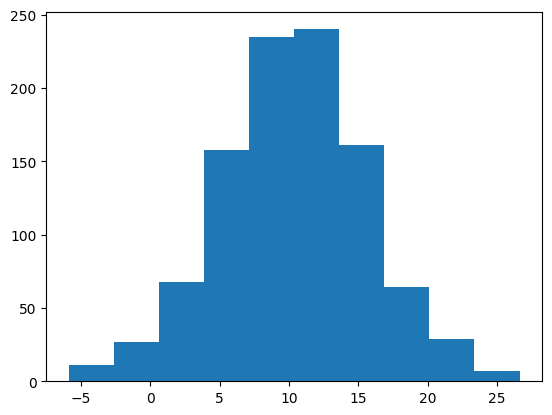

In [22]:
_=plt.hist(generate_normal(1000,10,5))

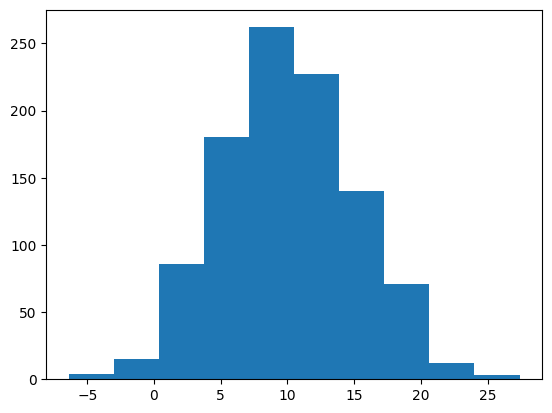

In [23]:
# Same thing with numpy (for reference)
import numpy as np
_=plt.hist(np.random.normal(loc=10., scale=5.0, size=1000))

Back to generating events...

Here's what we will do:
1. Simulate a Higgs decay in the rest frame... 

1. We need to create a candidate Higgs particle with energy drawn from a appropriate distribution. In this case, we will assume that the Higgs mostly start with speed of $(0.5 \pm 0.2) c$  (where $c$ is speed of light... we set c=1 here). So we'll use a normal distribution.

1. Use the Higgs energy to boost the decay to lab frame.

1. Decay the boosted Higgs to get the daughter particle momenta.

1. Store the information.

After doing this many times, we can look at the daughter particle energy distribution.

Each simulated collision is called an *event*. Everything about one event goes into a dictionary: the two photons, held together as a `composite`, and the boost the Higgs was given. A speed at or above the speed of light isn't physical, so the loop pulls any such draw back down to $0.9c$.

In [24]:
Events=[]

N_Events=100

for i in range(N_Events):
    p_H=four_vector([m_H,0.,0.,0.])
    my_boost= generate_normal(1,.5,.2)[0]
    if my_boost>=1.:
        my_boost=.9
    #print(my_boost)
    p_Hb=p_H.boost([0.,my_boost,0.])
    
    p1,p2=decay(p_Hb)
    
    Event= {"Higgs":composite([p1,p2]),
            "Boost":my_boost}
    
    Events.append(Event)
    
# Make sure the decay products add back to the Higgs
for i,Event in enumerate(Events):
    print ("Event:",i)
    print ("Higgs 4-vector:",Event["Higgs"])
    print ("Boost:",Event["Boost"])


Event: 0
Higgs 4-vector: (147.50332961431388, 0.0, 78.30857071425154, 0.0)
Boost: 0.5308935799551766
Event: 1
Higgs 4-vector: (133.80383662357144, 0.0, 47.733287077126704, 0.0)
Boost: 0.3567407951941925
Event: 2
Higgs 4-vector: (141.91919911307846, 0.0, 67.20163001667154, 0.0)
Boost: 0.47352035832112177
Event: 3
Higgs 4-vector: (136.37590220938296, 0.0, 54.52876950219188, 0.0)
Boost: 0.3998416774429243
Event: 4
Higgs 4-vector: (143.0832169072607, 0.0, 69.62619449984474, 0.0)
Boost: 0.48661328704241336
Event: 5
Higgs 4-vector: (127.17002503756683, 0.0, 23.392632773062886, 0.0)
Boost: 0.1839476933825605
Event: 6
Higgs 4-vector: (179.4072170556374, 0.0, 128.6932380960577, 0.0)
Boost: 0.7173247554257955
Event: 7
Higgs 4-vector: (135.00021013558975, 0.0, 50.99075148155191, 0.0)
Boost: 0.37770868230751997
Event: 8
Higgs 4-vector: (159.12063561293118, 0.0, 98.4600257864237, 0.0)
Boost: 0.6187759708673649
Event: 9
Higgs 4-vector: (128.05161943096493, 0.0, 27.788797003337166, 0.0)
Boost: 0.2170

In [25]:
len(Events)

100

Now the thing we set out to find. For each event, take the `composite` Higgs, ask it for its first daughter, and take the zeroth component of that photon's four-vector, its energy. Then histogram the list:

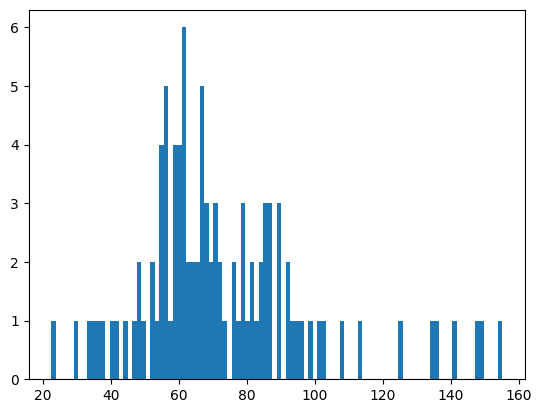

In [26]:
_=plt.hist([an_event["Higgs"].daughters[0].v[0] for an_event in Events],bins=100)

In the Higgs' rest frame, each photon would have exactly half the Higgs mass, 62.5 GeV. In the lab, a photon thrown forward, along the Higgs' motion, gains energy, and one thrown backward loses it, so the energies spread out on both sides of 62.5 GeV. Here most land between about 35 and 100 GeV, and the fastest Higgs bosons give a few photons past 150 GeV. The `random.seed` call in the `decay` cell makes every run produce the same events. Change the seed, or remove it, to see a different sample, and since 100 events is a small sample, run more to see the shape clearly. That range is what a detector for this search has to measure well, and it tells you which technologies for measuring photon energies are worth investigating.

The same recipe works well beyond particle physics. Build a simple model of how a system behaves, draw its starting conditions, and whatever is random along the way, from reasonable distributions, run it many times, and study the outcome. To compare designs for a computer network, for example, you could model computers that each send traffic with some random behavior, and try different layouts of the network to see which works best. Then change the model (what if it were twice as big?) and run it again. The one-dimensional distribution generators you've been writing are the very first piece of this. Real experiments run an enormously more detailed version: it simulates the passage of every particle through every element of the detector and the electronics' response, so that what comes out is data in exactly the same form as the real experiment produces. Software of that kind, for simulating particles passing through matter, is also used in medical physics and in satellite design.

## Drawing Program Example

Next work through how a drawing program would work. We will separate the problem into two parts:

1. A canvas that holds pixel values, which we can set as needed, and can display itself.
1. Shape objects that hold information about specific shapes (like circle or rectangle), and know how to set pixels on a canvas to display themselves.

### Canvas

This is the same distinction that showed up with histograms: what you keep in memory and what you draw on screen are two different things. A histogram's real content is the bin counts; the picture is just one way of displaying that content, computed separately from it. A drawing is the same — "a box here, a circle there" can be kept as a description in memory, entirely separate from the business of actually putting characters (or pixels) on a screen or a page.

In order to keep things simple, we'll do everything with text graphics. Our canvas is going to be just a grid of characters. Here is the implementation:

In [27]:
class Canvas:
    def __init__(self, width, height):
        self.width = width
        self.height = height
        # Empty canvas is a matrix with element being the "space" character
        self.data = [[' '] * width for i in range(height)]

    def set_pixel(self, row, col, char='*'):
        self.data[row][col] = char

    def get_pixel(self, row, col):
        return self.data[row][col]
    
    def clear_canvas(self):
        self.data = [[' '] * self.width for i in range(self.height)]
    
    def v_line(self, x, y, h, **kargs):
        for i in range(x,x+h):
            self.set_pixel(i,y, **kargs)

    def h_line(self, x, y, w, **kargs):
        for i in range(y,y+w):
            self.set_pixel(x,i, **kargs)
            
    def line(self, x1, y1, x2, y2, **kargs):
        slope = (x2-x1) / (y2-y1)
        for y in range(y1,y2):
            x= x1 + int(slope * (y-y1))
            self.set_pixel(x,y, **kargs)
            
    def display(self):
        print("\n".join(["".join(row) for row in self.data]))

A couple of quick tests:

In [28]:
my_canvas = Canvas(10,10)
my_canvas.set_pixel(0,0,char='A')
my_canvas.v_line(1,1,4,char='|')
my_canvas.h_line(1,1,3,char='-')
my_canvas.line(3,3,7,6,char='\\')

my_canvas.display()

A         
 ---      
 |        
 | \      
 |  \     
     \    
          
          
          
          


In [29]:
c1=Canvas(40,40)
c1.v_line(1,1,5,char='|')
c1.h_line(3,3,4)
c1.line(4,4,30,20)
c1.display()

                                        
 |                                      
 |                                      
 | ****                                 
 |  *                                   
 |   *                                  
                                        
      *                                 
       *                                
                                        
        *                               
                                        
         *                              
          *                             
                                        
           *                            
                                        
            *                           
             *                          
                                        
              *                         
               *                        
                                        
                *                       
                

The canvas is our display, and it is an abstraction barrier too. Here it's a grid of characters, like an old text terminal. It could just as well be a window on a screen, or a printer putting a page down pixel by pixel at much higher resolution. Whatever draws on it only needs to know how to set pixels and how to ask it to display itself.

Here is the data that the canvas stores:

In [30]:
c1.data

[[' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' '],
 [' ',
  '|',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' '],
 [' ',
  '|',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' '],
 [' ',
  '|',
  ' ',
  '*',
  '*',
  '*',
  '*',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  '

In [31]:
c1.display()

                                        
 |                                      
 |                                      
 | ****                                 
 |  *                                   
 |   *                                  
                                        
      *                                 
       *                                
                                        
        *                               
                                        
         *                              
          *                             
                                        
           *                            
                                        
            *                           
             *                          
                                        
              *                         
               *                        
                                        
                *                       
                

### Shapes

Shapes are the other representation of a drawing: instead of pixels, instructions for making them. Draw a line from here to there, put a rectangle here. Taken together they make a tiny drawing language.

Each shape can carry a name. A drawing may hold thousands of lines, and a name is how you find the one you want. The `**kwargs` in the constructors is a way to pass options down through several calls. Create a `Rectangle` with the option `char="^"` and it keeps that option. When it paints, it hands the option to `v_line` and `h_line`, which hand it on to `set_pixel`, which finally uses it. The option travels three calls deep without any function in between having to know about it. Libraries like matplotlib use this pattern all the time.

For shapes, we will define a base class which all shapes inherit from:

In [32]:
class Shape:
    def __init__(self, name="", **kwargs):
        self.name=name
        self.kwargs=kwargs
    
    def paint(self, canvas): pass

class Rectangle(Shape):
    def __init__(self, x, y, w, h, **kwargs):
        Shape.__init__(self, **kwargs)
        self.x = x
        self.y = y
        self.w = w
        self.h = h

    def paint(self, canvas):
        canvas.h_line(self.x, self.y, self.w+1, **self.kwargs)
        canvas.h_line(self.x + self.h, self.y, self.w+1, **self.kwargs)
        canvas.v_line(self.x, self.y, self.h+1, **self.kwargs)
        canvas.v_line(self.x, self.y + self.w, self.h+1, **self.kwargs)

class Square(Rectangle):
    def __init__(self, x, y, size, **kwargs):
        Rectangle.__init__(self, x, y, size, size, **kwargs)

class Line(Shape):
    def __init__(self, x1, y1, x2, y2,  **kwargs):
        Shape.__init__(self, **kwargs)
        self.x1=x1
        self.y1=y1
        self.x2=x2
        self.y2=y2
        
    def paint(self, canvas):
        canvas.line(self.x1,self.y1,self.x2,self.y2, **self.kwargs)
        
class CompoundShape(Shape):
    def __init__(self, shapes, **kwargs):
        Shape.__init__(self, **kwargs)
        self.shapes = shapes

    def paint(self, canvas):
        for s in self.shapes:
            s.paint(canvas)

Quick test:

In [33]:
c1=Canvas(50,40)
s1=Rectangle(5,5,10,5,char="^")
s1.paint(c1)
c1.display()
# l1=Line(2,2,13,19)
# l1.paint(c1)

                                                  
                                                  
                                                  
                                                  
                                                  
     ^^^^^^^^^^^                                  
     ^         ^                                  
     ^         ^                                  
     ^         ^                                  
     ^         ^                                  
     ^^^^^^^^^^^                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                               

In [34]:
c1=Canvas(50,40)
s1=Square(5,5,20,char="^")
s1.paint(c1)
l1=Line(2,2,13,19)
l1.paint(c1)

In [35]:
c1.display()

                                                  
                                                  
  **                                              
    **                                            
      *                                           
     ^^**^^^^^^^^^^^^^^^^^                        
     ^   *               ^                        
     ^    **             ^                        
     ^      *            ^                        
     ^       **          ^                        
     ^         *         ^                        
     ^          **       ^                        
     ^            *      ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^     

A `CompoundShape` is what *group* does in a slide program: several shapes held together and drawn as one. It also saves bookkeeping. An object that nothing refers to goes away, so every shape needs a reference. Rather than keeping a variable for every shape in a complicated picture, you can put them all in a list inside one compound shape and keep a single reference to that.

Lets test compound shape:

In [36]:
c1=Canvas(50,40)
s1=CompoundShape([Square(5,5,20,char="^"),
                  Line(2,2,13,19)])
s1.paint(c1)

In [37]:
c1.display()

                                                  
                                                  
  **                                              
    **                                            
      *                                           
     ^^**^^^^^^^^^^^^^^^^^                        
     ^   *               ^                        
     ^    **             ^                        
     ^      *            ^                        
     ^       **          ^                        
     ^         *         ^                        
     ^          **       ^                        
     ^            *      ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^     

This is where the shared `paint` interface pays off. Someone could write a brand-new `Star` shape and hand it to us. We wouldn't need to know anything about it: put it in the list with the others, tell each one to paint, and the star does the right thing, even though we're treating it as a generic shape. And when we do need to, we can ask a shape whether it's a star, with `isinstance`, and deal with it as one.

Note that we are using polymorphism to treat specific objects line square and line as shapes:

In [38]:
shapes = list()

shapes.append(Square(5,5,20,char="^"))
shapes.append(Line(2,2,13,19))

c1=Canvas(50,40)
for shape in shapes:
    shape.paint(c1)
c1.display()

                                                  
                                                  
  **                                              
    **                                            
      *                                           
     ^^**^^^^^^^^^^^^^^^^^                        
     ^   *               ^                        
     ^    **             ^                        
     ^      *            ^                        
     ^       **          ^                        
     ^         *         ^                        
     ^          **       ^                        
     ^            *      ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^     

### Drawing

What if we wanted to create a drawing consisting of multiple shapes, view it, and then change the drawing, like make an object larger? All we have to do is to keep track of (book keep) all the objects in the drawing, have a means of finding the object that we want to change, change the object, and then redraw on a canvas.

This is also the reason for the split into `Canvas` and shapes in the first place: a canvas by itself has no memory of *why* a pixel has the value it does, so changing a drawing after the fact means starting over. Keeping the shapes themselves, not just their rendered pixels, is what makes editing possible.

This is what a slide or drawing program does. Each tool you click creates an object of some type in memory, a circle for instance, and tells it to render itself on the screen. When you click on the circle later, the program finds it among the objects it's keeping. When you drag to make it bigger, the program changes that object's parameters and draws it again. A `RasterDrawing` also takes care of references for you. You hand it each shape, it gives the shape a name if it doesn't already have one, and it holds on to it, so you don't have to keep a variable for every object you've drawn.

Lets introduce a `RasterDrawing` class that would facilitate with these steps:

In [39]:
class RasterDrawing:
    def __init__(self):
        self.shapes=dict()
        self.shape_names=list()
        
    def add_shape(self,shape):
        if shape.name == "":
            shape.name = self.assign_name()
        
        self.shapes[shape.name]=shape
        self.shape_names.append(shape.name)

    def update(self, canvas):
        canvas.clear_canvas()
        self.paint(canvas)
        
    def paint(self,canvas):
        for shape_name in self.shape_names:
            self.shapes[shape_name].paint(canvas)
            
    def assign_name(self):
        name_base="shape"
        name = name_base+"_0"
        
        i=1
        while name in self.shapes:
            name = name_base+"_"+str(i)
            i+=1
            
        return name

Quick tests:

In [40]:
c1=Canvas(50,40)
rd=RasterDrawing()

rd.add_shape(Square(5,5,20,char="^"))
print(rd.shapes)
rd.add_shape(Line(2,2,13,19))
print(rd.shapes)
rd.paint(c1)

c1.display()

{'shape_0': <__main__.Square object at 0x10ec57ce0>}
{'shape_0': <__main__.Square object at 0x10ec57ce0>, 'shape_1': <__main__.Line object at 0x10ec57a80>}
                                                  
                                                  
  **                                              
    **                                            
      *                                           
     ^^**^^^^^^^^^^^^^^^^^                        
     ^   *               ^                        
     ^    **             ^                        
     ^      *            ^                        
     ^       **          ^                        
     ^         *         ^                        
     ^          **       ^                        
     ^            *      ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^                        
     ^                   ^  

Looks like it works. Note that we can use the same raster drawing to draw on different a canvas:

In [41]:
c1=Canvas(40,40)
rd.paint(c1)
c1.display()

                                        
                                        
  **                                    
    **                                  
      *                                 
     ^^**^^^^^^^^^^^^^^^^^              
     ^   *               ^              
     ^    **             ^              
     ^      *            ^              
     ^       **          ^              
     ^         *         ^              
     ^          **       ^              
     ^            *      ^              
     ^                   ^              
     ^                   ^              
     ^                   ^              
     ^                   ^              
     ^                   ^              
     ^                   ^              
     ^                   ^              
     ^                   ^              
     ^                   ^              
     ^                   ^              
     ^                   ^              
     ^          

Now lets see if we can change an object and see how it affects the drawing:

In [42]:
rd.shapes["shape_0"].w=1
rd.update(c1)
c1.display()

                                        
                                        
  **                                    
    **                                  
      *                                 
     ^^**                               
     ^^  *                              
     ^^   **                            
     ^^     *                           
     ^^      **                         
     ^^        *                        
     ^^         **                      
     ^^           *                     
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^         

Why didn't this work? Because we didn't redraw on the canvas, so we are just seeing what we drew before. Try again:

In [43]:
c2=Canvas(40,40)
rd.paint(c2)
c2.display()

                                        
                                        
  **                                    
    **                                  
      *                                 
     ^^**                               
     ^^  *                              
     ^^   **                            
     ^^     *                           
     ^^      **                         
     ^^        *                        
     ^^         **                      
     ^^           *                     
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^                                 
     ^^         

Now we see the drawing has changed.

## The point of this exercise

A `RasterDrawing` is doing the same job as a PDF file or a Keynote file: a saved description of objects and how to draw them, not a picture. That's also what a plotting library like matplotlib is doing underneath — you hand it a description of what you want (a line here, a set of points there), and it renders that description when asked. Next lecture picks this up directly: you'll take this `Canvas`, build your own shape classes on top of it, and then write the save/load code that turns a `RasterDrawing` into an actual file on disk and back.